# Desafio Segmentación de Clientes

Se hará un análisis, intentando ser lo más breve para que la revisión del código sea rápida pero sin perder la calidad del análisis.

In [1]:
# importar librerías
import pandas as pd
import numpy as np
# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
pio.renderers.default = "jpg"

# EDA + Limpieza

In [2]:
df = pd.read_csv("data_customers.csv") 

In [3]:
df.head(2)

,fullVisitorId,channelGrouping,weekend_prop,hour,sessionId,device.browser,device.deviceCategory,device.isMobile,device.operatingSystem,totals.hits,totals.pageviews,bounce_prop,trafficSource.medium
0,213131142648941,Direct,0.000000,22.0,1,Chrome,desktop,0.0,Macintosh,14.0,13.0,0.0,(none)
1,435324061339869,Referral,0.666667,21.0,3,Chrome,desktop,0.0,Macintosh,14.0,11.0,0.0,referral


In [4]:
df.shape

(9996, 13)

In [5]:
df.isnull().any()

fullVisitorId             False
channelGrouping           False
weekend_prop              False
hour                      False
sessionId                 False
device.browser            False
device.deviceCategory     False
device.isMobile           False
device.operatingSystem    False
totals.hits               False
totals.pageviews          False
bounce_prop               False
trafficSource.medium      False
dtype: bool

Puntos importantes:
- No hay nulos 
- Hay variables númericas y Categoricas (Para númericas ideal Kmeans y para categoricas existen otros métodos como K-Modes)

Por otra parte hay una relación entre las columnas con prefijo device: deviceCategory,browser, operatingSystem, isMobile.
Estás es necesario trabajarlas, de buena manera para extraer la info correcta.

## reduciendo info de device

In [6]:
# esta variable es necesaria para algunos análisis posteriores, luego de usarla se borrará.
# básicamente es para contar cada fila como 1 y sirve para contar registros similares
# en alguna métrica
df["numero_usuarios_1"] = 1

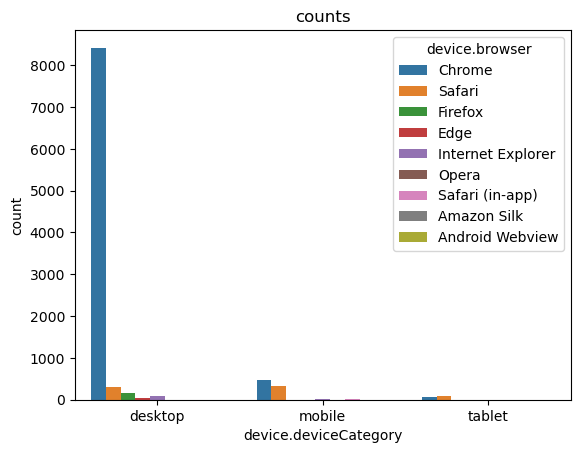

In [7]:
# Draw a nested barplot by species and sex
sns.countplot(x='device.deviceCategory', hue='device.browser' , data=df)
plt.title("counts")
plt.show()

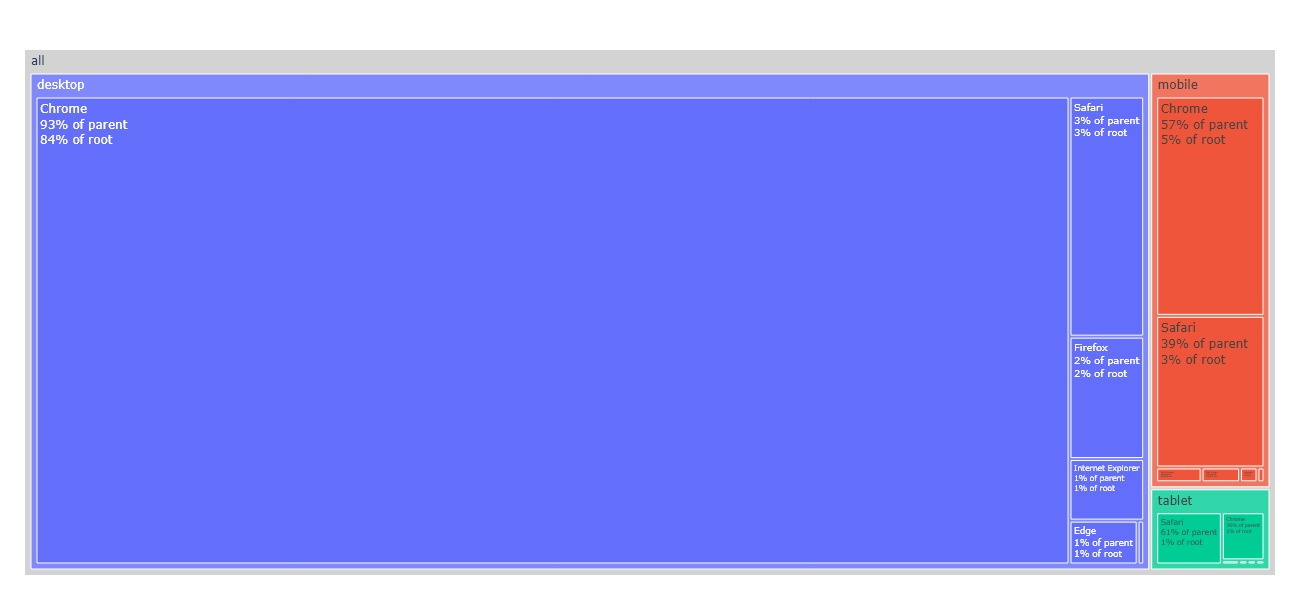

In [8]:
fig = px.treemap(
    df,
    path=[px.Constant("all"), "device.deviceCategory", "device.browser"],
    values="numero_usuarios_1",
    width=1300,
    height=600,
)
fig.update_traces(root_color="lightgrey", textinfo="label+percent parent+percent root")
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

84% de todas las visitas al sitio son de un computador usando chrome, el segundo grupo es mobile usando chrome (5%), safari usando desktop y mobile suman 6% (3% cada una) notemos con eso tenemos: 95% de las visitas, haremos en base a esto una limpieza... pero antes revisemos las últimas 2 columnas is mobile y sistema operativo.


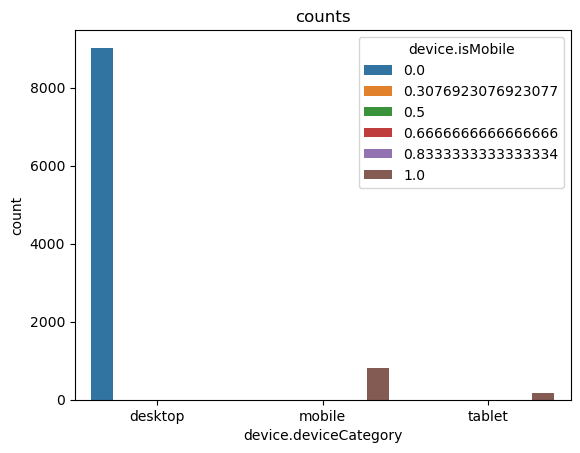

In [9]:
# Draw a nested barplot by species and sex
sns.countplot(x='device.deviceCategory', hue='device.isMobile' , data=df)
plt.title("counts")
plt.show()

tenemos aquí la data un poco sucia. Pero tenemos lo esperado 0 es el desktop y 1 son los mobile y table. Revisaremos estos casos que no son 1 o 0. (probablemente se borren, ya que no tiene sentido)

In [10]:
df[(df['device.isMobile']!= 1 ) & (df['device.isMobile']!= 0)]

,fullVisitorId,channelGrouping,weekend_prop,hour,sessionId,device.browser,device.deviceCategory,device.isMobile,device.operatingSystem,totals.hits,totals.pageviews,bounce_prop,trafficSource.medium,numero_usuarios_1
1013,455718321769006834,Organic Search,0.000000,2.0,2,Chrome,desktop,0.500000,Android,41.5,33.0,0.500000,organic,1
3968,3207713058277296455,Direct,0.000000,4.0,3,Chrome,mobile,0.666667,Android,51.0,42.0,0.000000,(none),1
7701,7376750587981554489,Organic Search,0.000000,8.0,6,Chrome,mobile,0.833333,Android,2.5,2.5,0.500000,organic,1
9708,9669933764937008223,Organic Search,0.307692,16.0,13,Chrome,mobile,0.307692,Linux,1.0,1.0,0.538462,organic,1


El primer elemento esta extraño desktop y android de sistema operativo, acá hay dos opciones usar categoria como para definir el valor, si es desktop es 0 de lo contrario 1. O la otra opción es borrarlos porque no se confia en el registro, dado que son 4 registros de casi 10 mil se borraran.

In [11]:
df = df[(df['device.isMobile']== 1 ) | (df['device.isMobile']== 0)]

In [12]:
df.shape

(9992, 14)

In [13]:
# columna device esta ordenada, los más comunes grupo 1, los menos el 2 y así para resumir información

In [14]:
#df['device.deviceCategory'].unique()
#df['device.browser'].unique()
df['device'] = 5

In [15]:
# tenemos aquí el 95% de los equipos
df.loc[(df['device.deviceCategory'] == 'desktop') & (df['device.browser'] == 'Chrome'), 'device'] = 1 #'most_common_device'
df.loc[(df['device.deviceCategory'] == 'mobile') & (df['device.browser'] == 'Chrome'), 'device'] = 2 #'second_common_device'
df.loc[(df['device.deviceCategory'] == 'mobile') & (df['device.browser'] == 'Safari'), 'device'] = 3 #'third_common_device'
df.loc[(df['device.deviceCategory'] == 'desktop') & (df['device.browser'] == 'Safari'), 'device'] = 4 # 'third_common_device'

In [16]:
df.device.value_counts()

1    8418
5     487
2     457
3     318
4     312
Name: device, dtype: int64

In [17]:
df = df.drop(columns=['device.deviceCategory', 'device.browser','device.isMobile','device.operatingSystem'])

## reduciendo info de trafico

In [18]:
df.columns

Index(['fullVisitorId', 'channelGrouping', 'weekend_prop', 'hour', 'sessionId',
       'totals.hits', 'totals.pageviews', 'bounce_prop',
       'trafficSource.medium', 'numero_usuarios_1', 'device'],
      dtype='object')

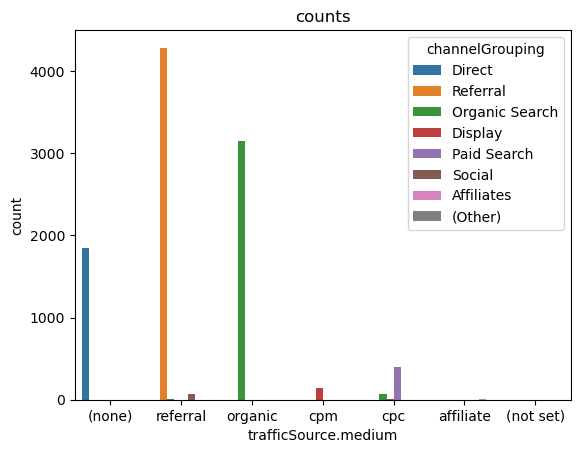

In [19]:
sns.countplot(x='trafficSource.medium', hue='channelGrouping' , data=df)
plt.title("counts")
plt.show()

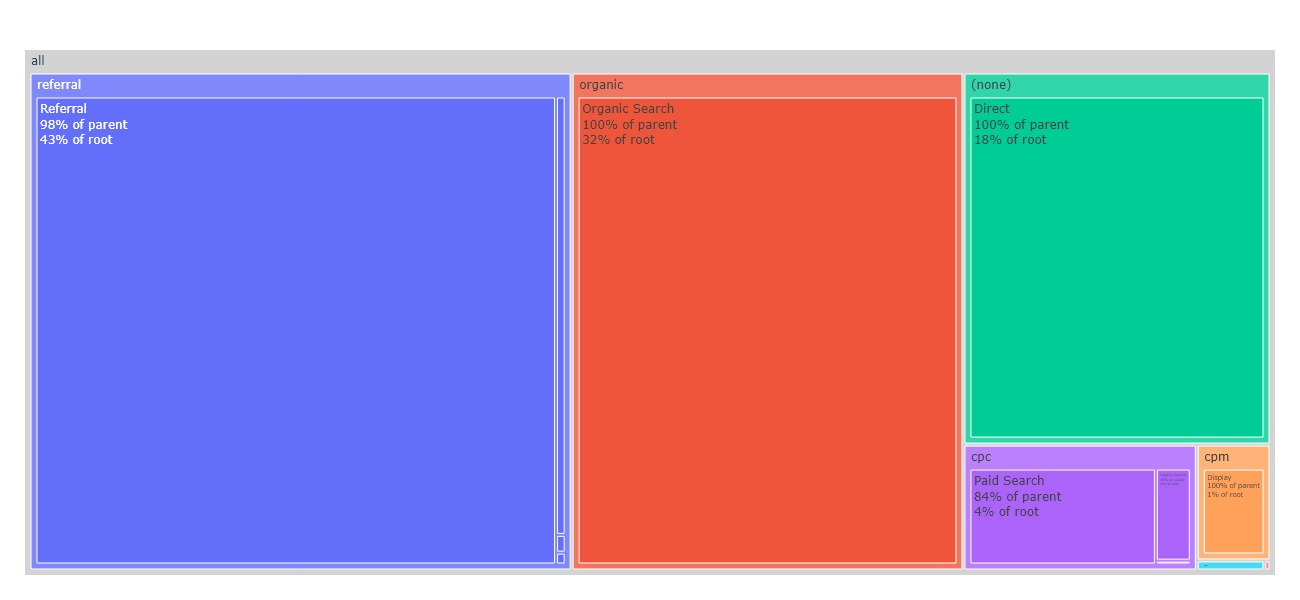

In [20]:
fig = px.treemap(
    df,
    path=[px.Constant("all"), "trafficSource.medium", "channelGrouping"],
    values="numero_usuarios_1",
    width=1300,
    height=600,
)
fig.update_traces(root_color="lightgrey", textinfo="label+percent parent+percent root")
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.show()

Aquí ocurre algo similar al caso anterior hay dos columnas que aportan casi la misma información. Hay casos extraños como CPC con organic search, en general las cajas muy chicas del gráfico de arriba es bueno revisar su calidad. Pero, como no se ha entrado al mundo en mayor detalle se dejará cómo está. Haciendo mismo ejercicio anterior. tenemos:

referral ->Referral 43%

Organic -> organic search 32% acumulado =75%

none ->direct 18%  acumulado =93%

cpc y cpm son muy bajos pero son canales pagado. Se incluira solo el cpc -> paid Search 4% acumulado =97%

El 5 será lo no incluido en grupo anterior.

In [21]:
df['trafficSource.medium'].unique()

array(['(none)', 'referral', 'organic', 'cpm', 'cpc', 'affiliate',
       '(not set)'], dtype=object)

In [22]:
df['channelGrouping'].unique()

array(['Direct', 'Referral', 'Organic Search', 'Display', 'Paid Search',
       'Social', 'Affiliates', '(Other)'], dtype=object)

In [23]:
df['traffic'] = 5

In [24]:
# tenemos aquí el 95% de los equipos
df.loc[(df['trafficSource.medium'] == 'referral') & (df['channelGrouping'] == 'Referral'), 'traffic'] = 1 #'most_common_traffic'
df.loc[(df['trafficSource.medium'] == 'organic') & (df['channelGrouping'] == 'Organic Search'), 'traffic'] = 2 #'second_common_traffic'
df.loc[(df['trafficSource.medium'] == '(none)') & (df['channelGrouping'] == 'Direct'), 'traffic'] = 3 #'third_common_traffic'
df.loc[(df['trafficSource.medium'] == 'cpc') & (df['channelGrouping'] == 'Paid Search'), 'traffic'] = 4 # 'third_common_traffic'

In [25]:
df.traffic.value_counts()

1    4286
2    3155
3    1847
4     400
5     304
Name: traffic, dtype: int64

In [26]:
# 
df = df.drop(columns=['trafficSource.medium', 'channelGrouping','numero_usuarios_1'])

## análisis nuevas variables

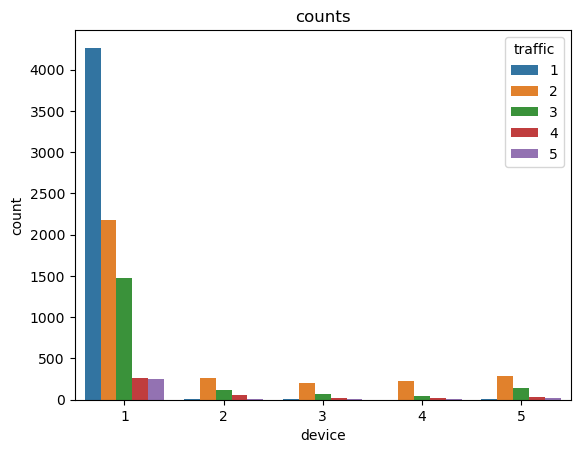

In [27]:
sns.countplot(x='device', hue='traffic' , data=df)
plt.title("counts")
plt.show()

Super interesante el trafico más comun ocurre solo con el dispositivo más comun (desktop + chrome), pero no en los otros. Dicho de otra forma, los equipos menos comunes ingresan de la segunda forma más común, es decir, de forma organica.

In [28]:
df.head(1)

,fullVisitorId,weekend_prop,hour,sessionId,totals.hits,totals.pageviews,bounce_prop,device,traffic
0,213131142648941,0.0,22.0,1,14.0,13.0,0.0,1,3


In [29]:
numerical_col = [col for col in df.columns if str(df[col].dtypes) in ["float64", "int64"]]
numerical_col

['weekend_prop',
 'hour',
 'sessionId',
 'totals.hits',
 'totals.pageviews',
 'bounce_prop',
 'device',
 'traffic']

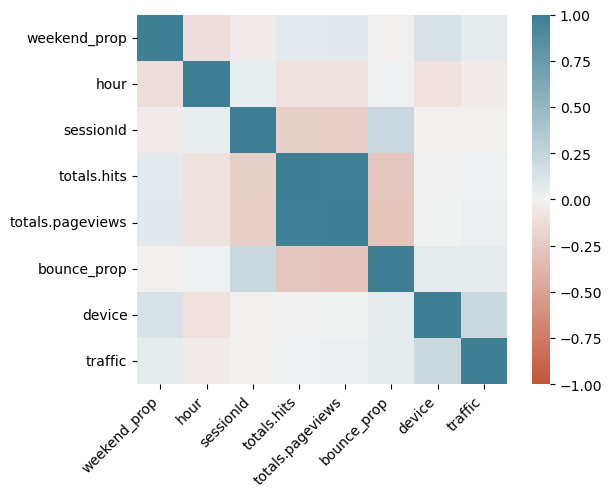

In [30]:
# mapa correlación
corr = df[numerical_col].corr()
ax = sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right");

Puntos importantes
- Device y trafico no se correlacionan mucho con el comportamiento de pagina (pageviews y hits).
- Device tiene un poco más de correlación de uso en la semana y la hora de uso. 
- En general, es importante notar que por su construcción device y traffic son categorias desbalanceadas.
- Las correlaciones más interesantes son total.hits indica que esta relacionado negativamente con la hora, la sesión y si fue un rebote. Por ora parte se relaciona muy positivamente con total.pageviews. Todas estas relaciones hacen sentido salvo la hora (corr baja de todas formas) y la de sesión. Sesiones en general son muy pocas id 54 (abajo calculo).

In [31]:
len(list(df.sessionId.unique()))

54

# Identificando Clúster

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import pandas as pd

def transformar_clustering_gmm(X, n_components=3, covariance_type="full"):
    """
    Aplica clustering con Gaussian Mixture Model (GMM) a datos numéricos.

    Parámetros
    ----------
    X : pd.DataFrame
        DataFrame de entrada con solo variables numéricas.
    n_components : int, default=3
        Número de componentes (clusters) en el modelo GMM.
    covariance_type : str, default="full"
        Tipo de covarianza para GaussianMixture ("full", "tied", "diag", "spherical").

    Retorna
    -------
    df_escalado : pd.DataFrame
        Versión escalada de X con etiquetas de cluster.
    df_original : pd.DataFrame
        Versión original de X con etiquetas de cluster.
    gmm : GaussianMixture
        Modelo GMM entrenado.
    """

    # Escalar las variables numéricas para que todas tengan la misma importancia
    scaler = StandardScaler()
    X_escalado = scaler.fit_transform(X)

    # Definir y entrenar el modelo Gaussian Mixture
    gmm = GaussianMixture(
        n_components=n_components,
        max_iter=1000,
        n_init=15,
        random_state=42,
        covariance_type=covariance_type,
    )
    gmm.fit(X_escalado)

    # Crear DataFrame con datos escalados y etiquetas de cluster
    df_escalado = pd.DataFrame(X_escalado, columns=X.columns)
    df_escalado["clusters"] = gmm.predict(X_escalado)

    # Crear DataFrame con datos originales y etiquetas de cluster
    df_original = X.copy()
    df_original["clusters"] = gmm.predict(X_escalado)

    return df_escalado, df_original, gmm


In [50]:
df = df.drop(columns=['fullVisitorId', 'sessionId'])

In [51]:
# probando diversos cluster
from sklearn.metrics import silhouette_score
import time

start_time = time.time()
number_clusters = [a for a in range(2, 7)]

silhoette_max = 0
index_max = -1
counter = 0
hyperparameters = ["full", "tied", "diag", "spherical"]
sil_dic = {}
for hyperparameter in hyperparameters:
    sil_list = []
    for clusters in number_clusters:
        df_escalado, df_original, gmm = transformar_clustering_gmm(
            df, n_components=clusters, covariance_type=hyperparameter
        )
        columns_without_clusters = [
            x for x in df_escalado.columns if x not in ["clusters"]
        ]
        silhoette = silhouette_score(
            df_escalado[columns_without_clusters], df_escalado["clusters"]
        )
        if silhoette > silhoette_max:
            silhoette_max = silhoette
            index_max = counter
        counter = counter + 1
        sil_list.append(silhoette)
    sil_dic[hyperparameter] = sil_list
print(f" Seconds to run: {(time.time() - start_time)}")


 Seconds to run: 75.82942938804626


In [52]:
df_sil = pd.DataFrame(
    {
        "cluster": number_clusters,
        "full": sil_dic["full"],
        "tied": sil_dic["tied"],
        "diag": sil_dic["diag"],
        "spherical": sil_dic["spherical"],
    }
)
df_sil

,cluster,full,tied,diag,spherical
0,2,0.183964,0.333696,0.183964,0.164643
1,3,0.173571,0.339543,0.174567,0.032922
2,4,0.182466,0.334104,0.151639,-0.032676
3,5,0.184475,0.294257,0.184297,0.121483
4,6,0.151531,0.275000,0.130915,0.162197


mejor es con 3 cluster tied.

## Entendiendo Clúster

In [53]:
df_escalado, df_original, gmm = transformar_clustering_gmm(
    df, n_components=3, covariance_type="tied"
)

Proporción de cada Cluster


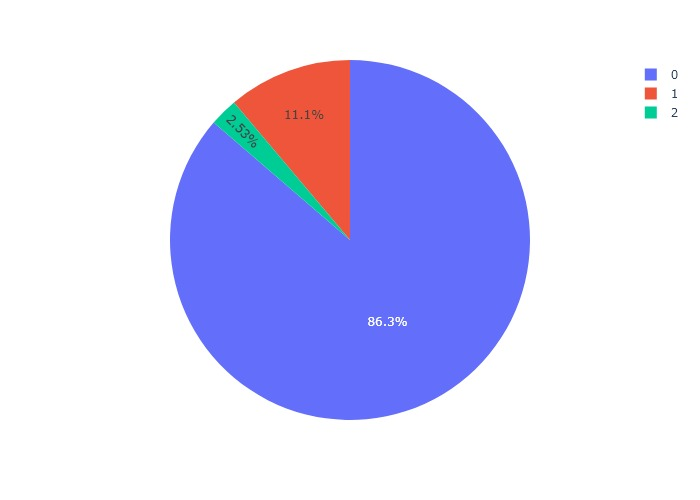

In [54]:
print("Proporción de cada Cluster")
df_escalado["numero_usuarios_1"] = 1
fig = px.pie(df_escalado, values="numero_usuarios_1", names="clusters")
fig.show()

In [55]:
df.columns

Index(['weekend_prop', 'hour', 'totals.hits', 'totals.pageviews',
       'bounce_prop', 'device', 'traffic'],
      dtype='object')

In [56]:
df_original.columns[:-1]

Index(['weekend_prop', 'hour', 'totals.hits', 'totals.pageviews',
       'bounce_prop', 'device', 'traffic'],
      dtype='object')

In [47]:
df_original

,fullVisitorId,weekend_prop,hour,sessionId,totals.hits,totals.pageviews,bounce_prop,device,traffic,clusters
0,213131142648941,0.000000,22.0,1,14.0,13.0,0.0,1,3,2
1,435324061339869,0.666667,21.0,3,14.0,11.0,0.0,1,1,2
2,562678147042735,0.000000,14.0,2,12.5,10.5,0.0,1,2,2
3,585708896049892,0.000000,20.0,1,22.0,20.0,0.0,1,1,2
4,670722016498267,0.000000,17.0,2,9.5,9.5,0.0,1,1,2
...,...,...,...,...,...,...,...,...,...,...
9991,9991633376050115277,0.000000,0.0,1,17.0,16.0,0.0,1,5,2
9992,9994767073213036303,0.000000,20.0,5,42.0,30.0,0.0,1,2,2
9993,9997409246962677759,0.000000,2.0,1,86.0,65.0,0.0,1,1,1
9994,9998597322098588317,0.000000,21.0,1,37.0,33.0,0.0,1,3,2


In [62]:
cluster_means = df_original.groupby("clusters").mean().reset_index()
#cluster_summary = df_original.groupby("clusters").agg(["mean", "std", "min", "max"])
print("Cluster means:")
print(cluster_means)


Cluster means:
   clusters  weekend_prop       hour  totals.hits  totals.pageviews  \
0         0      0.131855  14.723130    19.878841         16.000464   
1         1      0.254682  12.671454    21.765260         17.461849   
2         2      0.190711  13.041502   102.337945         69.952569   

   bounce_prop    device   traffic  
0     0.080641  1.052754  1.855072  
1     0.111950  4.151706  2.488330  
2     0.020026  1.043478  1.916996  


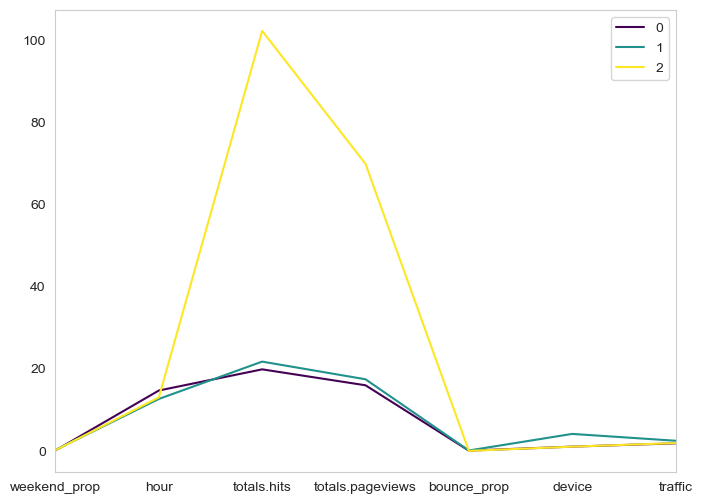

In [65]:
fig, ax = plt.subplots(figsize=(8, 6))
pd.plotting.parallel_coordinates(
    cluster_means,
    "clusters",
    colormap="viridis",
    use_columns=False,
    axvlines=False,
    ax=ax,
)

print(" ")

Aquí es mejor normalizar para ver mejor los grupos y características en diferencias a los otros.

## Graficando Centros de clúster

Notemos que todos tienen la misma covarianza, por lo que pese a que no son clúster circulares, el hecho que sean "Tied" hace que este análisis tenga sentido.

In [57]:
centroids = pd.DataFrame(gmm.means_, columns=df_original.columns[:-1])
centroids['cluster'] = range(gmm.n_components)
centroids

,weekend_prop,hour,totals.hits,totals.pageviews,bounce_prop,device,traffic,cluster
0,-0.050712,0.043217,-0.106681,-0.095605,-0.011473,-0.332892,-0.069848,0
1,0.363413,-0.284321,-0.018928,-0.004281,0.180807,2.655512,0.549560,1
2,0.122501,-0.212094,3.582461,3.156699,-0.390691,-0.341477,-0.039283,2


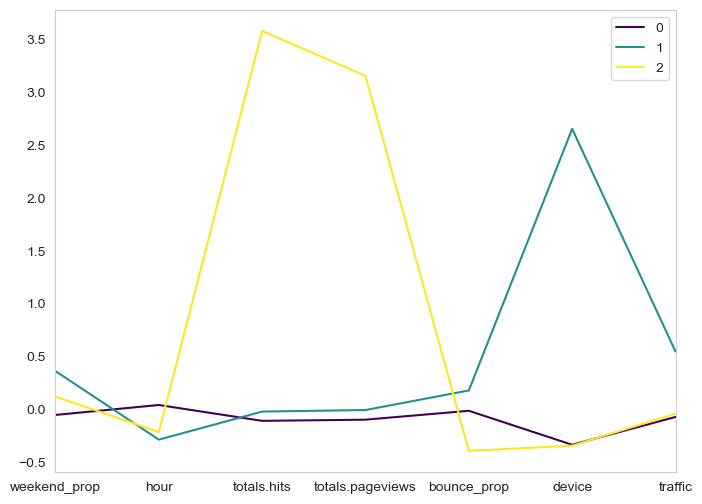

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))
pd.plotting.parallel_coordinates(
    centroids,
    "cluster",
    colormap="viridis",
    use_columns=False,
    axvlines=False,
    ax=ax,
)

print(" ")

Análizando gráfico de este gráfico más promedios de clúster (arriba)

Clúster 0 (grupo mayor en cantidad) (86% del total)

Grupo que tiene el equipo más comun (desktop + chrome) y llegan de la forma más comun. Son los que se conectan más tarde (promedio 14 hrs) y su comparmiento web es de revisar menos la página que los otros grupos (19-20 hits). En general son los que menos revisan el fin de semana (0.13). Este es el **visitante tradicional**.

Clúster 1 (11% del total)

Este grupo casi lo contrario al grupo anterior. Son los que se conectan más temprano desde un dispositivo no común, llegan de una forma innusual y se conectan los fin de semana. Navega un poco más por la página pero también rebotan más. **Visitante de fin de semanas, llego con mi equipo y de una forma no tan comun.** Este visitante, puede que no tenga la mejor experiencia si es que sitio web no esta adaptado a sus equipos y por eso tiene mayor rebote. Su compartamiento en el sitio es similar al clúster 0 pero toodo lo demás es lo más contrario que se puede.

Clúster 2. (2%)

Es el **super visitante** La hora, si es fin de semana, equipo (devise) o forma de llegar (trafico) todo normal pero su compartimiento parece que se quiere comer el sitio web.

Nótese varias cosas. Escogimos 3 clúster dado un algoritmo. Pero ese mismo algoritmo, mostraba que 4 clúster con hiperparametro "tied" también es una buena segmentación. Generar Clúster es un arte que requiere trabajar con el equipo en cuestión. Acá se previligio la matemática para desarrollar el problema.